# Bài tập thực hành tuần 6

> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Sáng thứ 6)

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import heapq
import sys
from time import perf_counter
from math import log2

### Bài tập:
**Câu hỏi**:

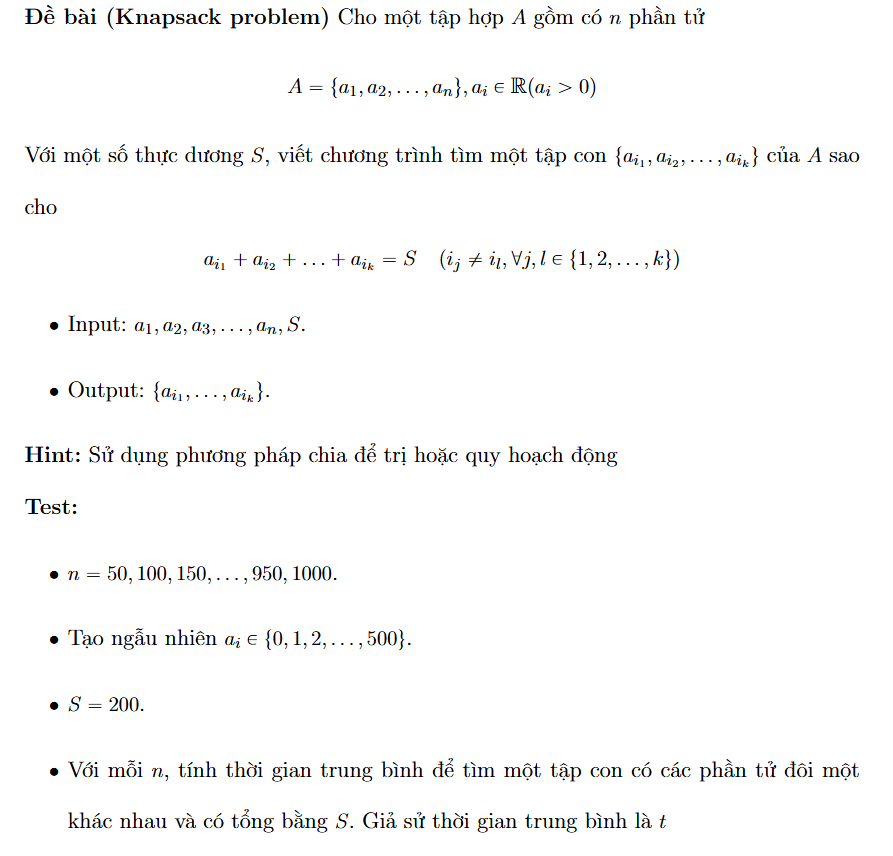

n = 50
  -Solution subset of 200: [78, 122]
  -Average Time: 0.000735s
n = 100
  -Solution subset of 200: [9, 46, 41, 56, 48]
  -Average Time: 0.001064s
n = 150
  -Solution subset of 200: [200]
  -Average Time: 0.001546s
n = 200
  -Solution subset of 200: [104, 13, 64, 19]
  -Average Time: 0.002059s
n = 250
  -Solution subset of 200: [37, 139, 24]
  -Average Time: 0.002514s
n = 300
  -Solution subset of 200: [152, 48]
  -Average Time: 0.003202s
n = 350
  -Solution subset of 200: [113, 55, 32]
  -Average Time: 0.003911s
n = 400
  -Solution subset of 200: [176, 24]
  -Average Time: 0.004582s
n = 450
  -Solution subset of 200: [31, 37, 82, 50]
  -Average Time: 0.005438s
n = 500
  -Solution subset of 200: [54, 146]
  -Average Time: 0.005766s
n = 550
  -Solution subset of 200: [78, 38, 19, 65]
  -Average Time: 0.006661s
n = 600
  -Solution subset of 200: [100, 85, 15]
  -Average Time: 0.006976s
n = 650
  -Solution subset of 200: [5, 42, 6, 147]
  -Average Time: 0.007475s
n = 700
  -Solution

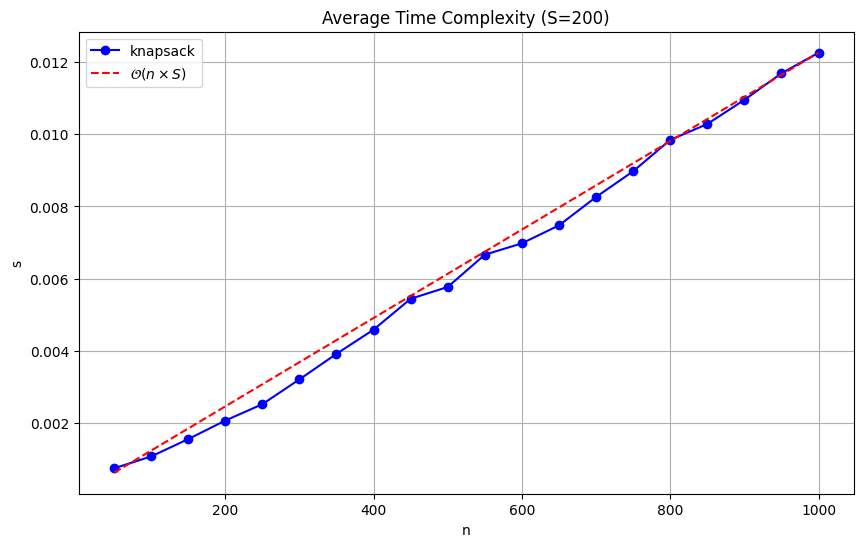

In [9]:
def generate_a(n):
    return [random.randint(0, 500) for _ in range(n)]

def knapsack(a, S):
    n = len(a)
    dp = [[False] * (S+1) for _ in range(n+1)]

    for i in range(n+1):
        dp[i][0] = True
    
    for i in range(1, n+1):
        for j in range(1, S+1):
            if j < a[i-1]:
                dp[i][j] = dp[i-1][j]
            else:
                dp[i][j] = dp[i-1][j] or dp[i-1][j-a[i-1]]
    
    if not dp[n][S]:
        return None

    result = []
    i, j = n, S
    while i > 0 and j > 0:
        if dp[i][j] and not dp[i-1][j]:
            result.append(a[i-1])
            j -= a[i-1]
        
        i -= 1

    return result

S = 200
NUM_TRIALS = 30 
avg_times = []
for n in range(50, 1001, 50):
    total_time = 0
    sample_result = None
    
    for _ in range(NUM_TRIALS):
        a = generate_a(n)

        tic = perf_counter()
        result = knapsack(a, S)
        toc = perf_counter()
        
        total_time += (toc - tic)
        sample_result = result 
        
    avg_time = total_time / NUM_TRIALS
    avg_times.append(avg_time)
    print(f'n = {n}')
    if sample_result:
        print(f'  -Solution subset of {S}: {sample_result}')
    else:
        print(f'  -No subset found that sums to {S}')
        
    print(f'  -Average Time: {avg_time:.6f}s')
    
    
n_values = list(range(50, 1001, 50))
C = avg_times[-1] / (n_values[-1] * S)
bigO_line = [C * (n * S) for n in n_values]

plt.figure(figsize=(10, 6))
plt.plot(n_values, avg_times, marker='o', color='blue', label='knapsack')
plt.plot(n_values, bigO_line, linestyle='--', color='red', label=r'$\mathcal{O}(n \times S)$')
plt.title('Average Time Complexity (S=200)')
plt.xlabel('n')
plt.ylabel('s')
plt.legend()
plt.grid(True)
plt.show()

Hàm `generate_a(n)` tạo ra một danh sách gồm n số nguyên ngẫu nhiên trong khoảng từ 0 đến 500.
```py
def generate_a(n):
    return [random.randint(0, 500) for _ in range(n)]
```

Hàm `knapsack(a, S)` thực hiện thuật toán quy hoạch động để giải quyết bài toán subset sum. Thuật toán này hoạt động theo các bước sau:
1. Tạo một bảng `dp` có kích thước (n+1) x (S+1) để lưu trữ kết quả của các bài toán con. `dp[i][j]` sẽ là `True` nếu có thể tạo ra tổng j bằng cách sử dụng một tập con của các phần tử đầu tiên i của mảng a, và `False` nếu không thể.
2. Khởi tạo cột đầu tiên của bảng `dp` là `True` vì có thể tạo ra tổng 0 bằng cách sử dụng tập con rỗng.
3. Điền bảng `dp` bằng cách lặp qua từng phần tử của mảng a và cập nhật bảng dựa trên việc có bao gồm phần tử hiện tại hay không.
    3.1. Nếu phần tử hiện tại lớn hơn tổng j, thì giá trị của `dp[i][j]` sẽ giống với `dp[i-1][j]` (không bao gồm phần tử này).
    3.2. Nếu phần tử hiện tại nhỏ hơn hoặc bằng tổng j, thì giá trị của `dp[i][j]` sẽ là `True` nếu có thể tạo ra tổng j bằng cách không bao gồm phần tử này (`dp[i-1][j]`) hoặc bằng cách bao gồm phần tử này (`dp[i-1][j-a[i-1]]`).
    3.3. Cập nhật bảng `dp` cho tất cả các giá trị của i và j.
4. Sau khi điền xong bảng `dp`, kiểm tra giá trị tại `dp[n][S]` để xác định xem có tồn tại một tập con của a có tổng bằng S hay không. Nếu không tồn tại, trả về `None`. Nếu tồn tại, xây dựng tập con kết quả bằng cách theo dõi lại bảng `dp` từ dưới lên trên.
    4.1. Bắt đầu từ `dp[n][S]`, nếu giá trị này là `True` và giá trị tại `dp[i-1][j]` là `False`, điều đó có nghĩa là phần tử a[i-1] đã được bao gồm trong tập con. Thêm phần tử này vào kết quả và giảm j đi giá trị của phần tử đó.
    4.2. Tiếp tục theo dõi lại bảng `dp` cho đến khi i hoặc j bằng 0.
5. Trả về tập con tìm được hoặc `None` nếu không có tập con nào thỏa mãn được tổng S.

```py
def knapsack(a, S):
    n = len(a)
    dp = [[False] * (S+1) for _ in range(n+1)]

    for i in range(n+1):
        dp[i][0] = True
    
    for i in range(1, n+1):
        for j in range(1, S+1):
            if j < a[i-1]:
                dp[i][j] = dp[i-1][j]
            else:
                dp[i][j] = dp[i-1][j] or dp[i-1][j-a[i-1]]
    
    if not dp[n][S]:
        return None

    result = []
    i, j = n, S
    while i > 0 and j > 0:
        if dp[i][j] and not dp[i-1][j]:
            result.append(a[i-1])
            j -= a[i-1]
        
        i -= 1

    return result
```

Chương trình chính thực hiện các bước sau:
1. Định nghĩa giá trị S và số lần thử nghiệm NUM_TRIALS.
2. Tạo một danh sách `avg_times` để lưu trữ thời gian trung bình cho mỗi kích thước n.
3. Sử dụng một vòng lặp để lặp qua các giá trị của n từ 50 đến 1000 với bước nhảy là 50.
4. Trong mỗi vòng lặp, tạo một biến `total_time` để tích lũy thời gian thực thi của các thử nghiệm và một biến `sample_result` để lưu trữ kết quả của một thử nghiệm mẫu.
5. Thực hiện NUM_TRIALS lần thử nghiệm cho mỗi n, trong đó:
   - Tạo một mảng a ngẫu nhiên bằng cách gọi hàm `generate_a(n)`.
   - Đo thời gian thực thi của hàm `knapsack(a, S)` và cộng thời gian này vào `total_time`.
   - Lưu trữ kết quả của thử nghiệm đầu tiên vào `sample_result` để in ra sau này.
6. Tính thời gian trung bình bằng cách chia `total_time` cho NUM_TRIALS và lưu trữ vào `avg_times`.
7. In ra kết quả của thử nghiệm mẫu và thời gian trung bình cho mỗi n.
8. Sau khi hoàn thành tất cả các thử nghiệm, vẽ đồ thị so sánh thời gian trung bình với đường O(n * S) để minh họa độ phức tạp thời gian của thuật toán.

```python
S = 200
NUM_TRIALS = 30 
avg_times = []
for n in range(50, 1001, 50):
    total_time = 0
    sample_result = None
    
    for _ in range(NUM_TRIALS):
        a = generate_a(n)

        tic = perf_counter()
        result = knapsack(a, S)
        toc = perf_counter()
        
        total_time += (toc - tic)
        sample_result = result 
        
    avg_time = total_time / NUM_TRIALS
    avg_times.append(avg_time)
    print(f'n = {n}')
    if sample_result:
        print(f'  -Solution subset of {S}: {sample_result}')
    else:
        print(f'  -No subset found that sums to {S}')
        
    print(f'  -Average Time: {avg_time:.6f}s')
    
    
n_values = list(range(50, 1001, 50))
C = avg_times[-1] / (n_values[-1] * S)
bigO_line = [C * (n * S) for n in n_values]

plt.figure(figsize=(10, 6))
plt.plot(n_values, avg_times, marker='o', color='blue', label='knapsack')
plt.plot(n_values, bigO_line, linestyle='--', color='red', label=r'$\mathcal{O}(n \times S)$')
plt.title('Average Time Complexity (S=200)')
plt.xlabel('n')
plt.ylabel('s')
plt.legend()
plt.grid(True)
plt.show()
```

Kết quả từ đồ thị cho thấy thời gian trung bình của thuật toán knapsack có xu hướng tăng theo n và S, và nó rất giống với đường O(n * S), chứng tỏ rằng độ phức tạp thời gian của thuật toán này là O(n * S).
